In [1]:
library(stars)
library(hmmTMB)

source("../R/hmm_helpers.R")

Loading required package: abind

Loading required package: sf

Linking to GEOS 3.14.1, GDAL 3.8.5, PROJ 9.5.1; sf_use_s2() is TRUE

Loading required package: R6

Loading required package: mgcv

Loading required package: nlme

This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: TMB

Loading required package: ggplot2



In [2]:
options(
  repr.plot.width = 14,
  repr.plot.height = 5
)

## Load kymogram (space/time plot) of a cortical capillary 

In [3]:
kymogram <- t(read_ncdf("../data/xt_cap1.nc")$CONA_AF594_subtracted)[1:1680, 13:40]

no 'var' specified, using CONA_AF594, CONA_DARK, WGA_AF488, WGA_DARK, CONA_AF594_subtracted, WGA_AF488_subtracted

other available variables:
 t, x

Will return stars object with 520000 cells.

Warning message in .get_nc_projection(meta$attribute, rep_var, cv):
"No projection information found in nc file."


## Visualize kymogram: dark shadows are RBCs passing through a capillary

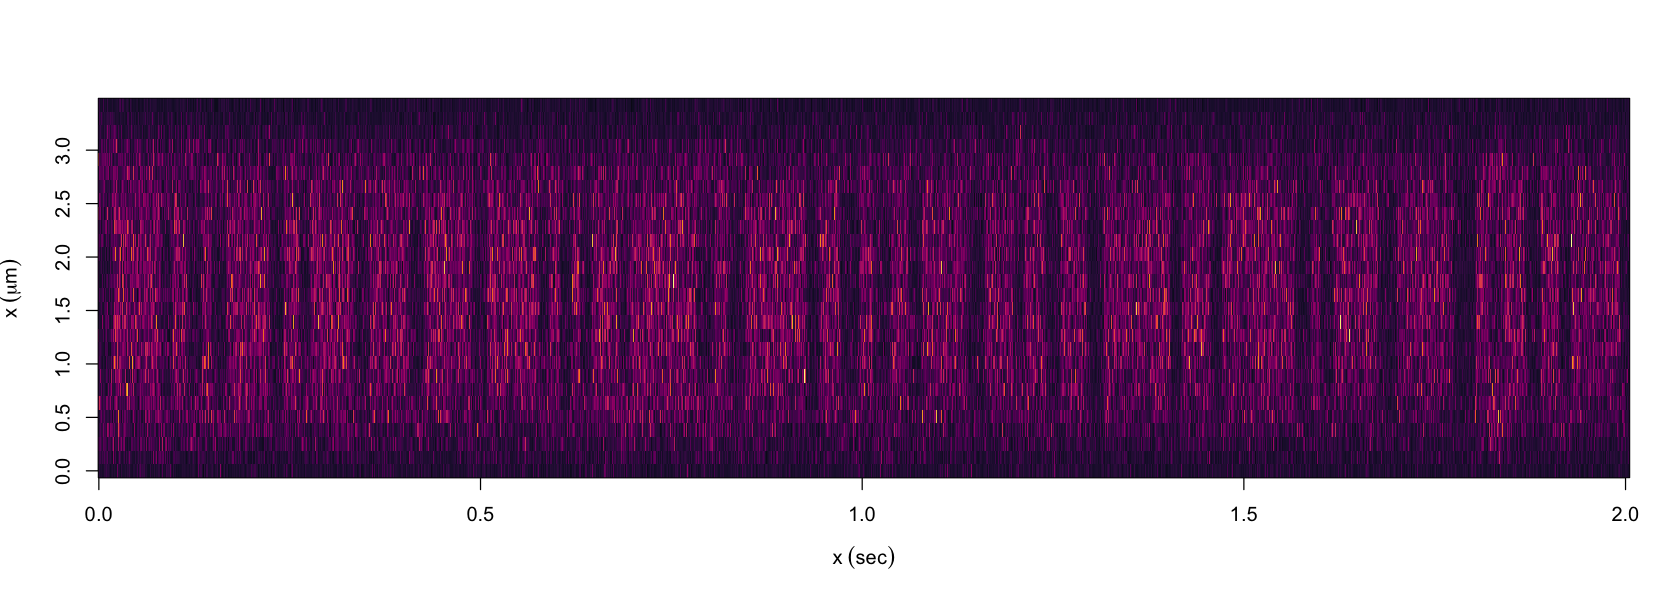

In [4]:
# Set physical dimensions of teh kymogram
pixel_size_x <- 0.001194  # sec per pixel
pixel_size_y <- 0.1267  # µm per pixel

x_t <- seq(
  from = 0,
  by = pixel_size_x,
  length.out = nrow(kymogram)
)

y_um <- seq(
  from = 0,
  by = pixel_size_y,
  length.out = ncol(kymogram)
)

## Plot kymogram
image(kymogram, 
    col = hcl.colors(256, "Inferno"),
    x = x_t,
    y = y_um,
    ylab = expression(x~(mu*m)),
    xlab = expression(x~(sec)),
    # asp=0.1,
   useRaster = TRUE)

## Select a region of the kymogram containing only the lumen

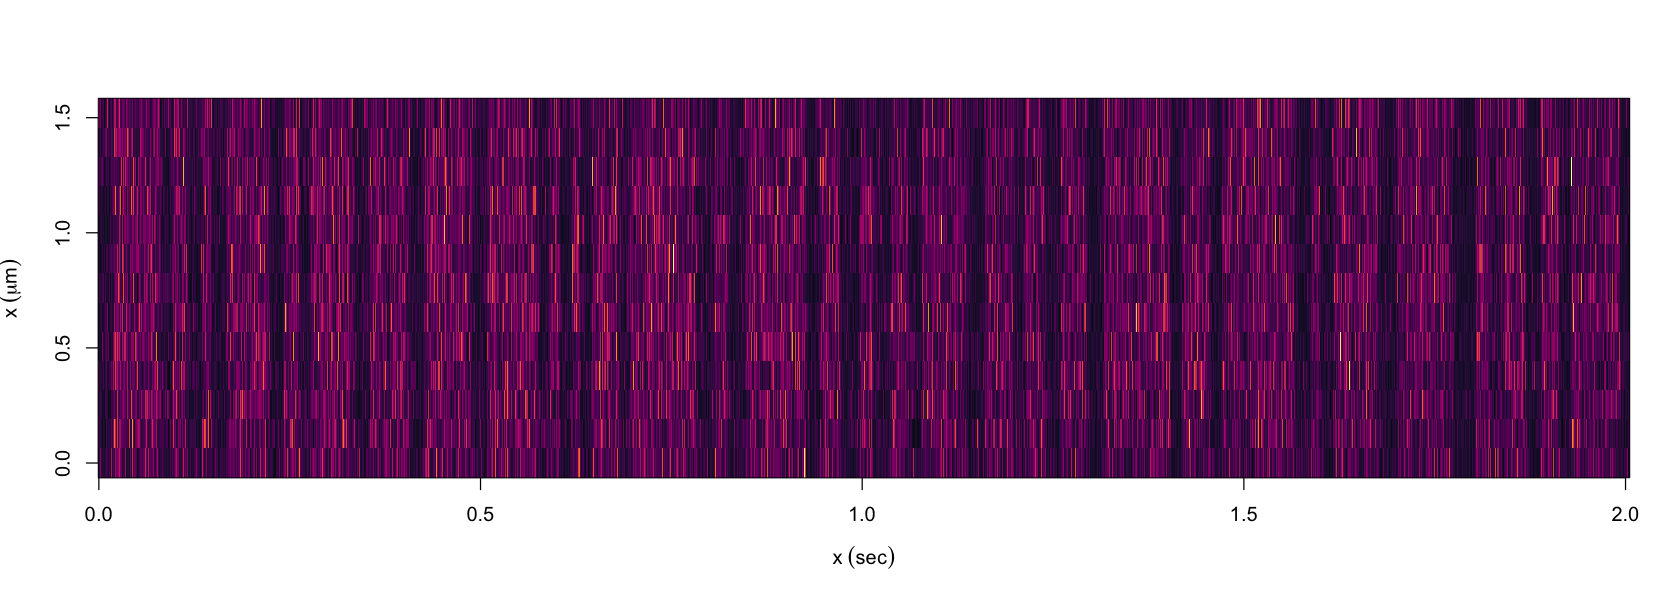

In [5]:
kymogram_lumen <- kymogram[, 8:20]

x_t <- seq(
  from = 0,
  by = pixel_size_x,
  length.out = nrow(kymogram_lumen)
)

y_um <- seq(
  from = 0,
  by = pixel_size_y,
  length.out = ncol(kymogram_lumen)
)

## Plot kymogram
image(kymogram_lumen, 
    col = hcl.colors(256, "Inferno"),
    x = x_t,
    y = y_um,
    ylab = expression(x~(mu*m)),
    xlab = expression(x~(sec)),
   useRaster = TRUE)

## Average kymogram over x-coordinate 

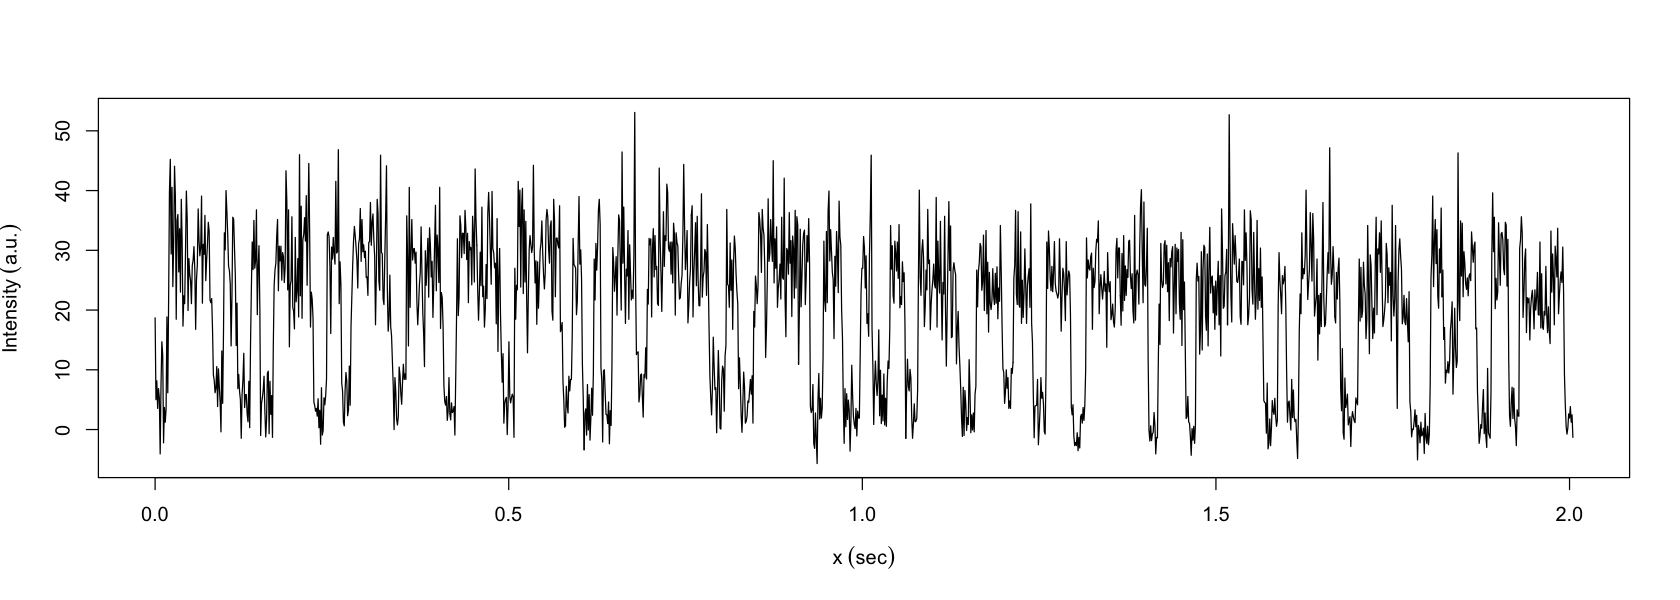

In [6]:
lumen_aver_intensity <- rowMeans(kymogram_lumen)

plot(x_t, lumen_aver_intensity, type = "l",
    xlab=expression(x~(sec)),
    ylab=expression(Intensity~(a.u.)),
    )

In [7]:
dat <- data.frame(
  time = x_t,
  value = lumen_aver_intensity
)

## Create a HMM

> Estimated observation parameters (t = 1):
           state 1 state 2
value.mean   4.118  26.572
value.sd     4.320   6.826

> Estimated transition probabilities (t = 1):
        state 1 state 2
state 1   0.934   0.066
state 2   0.029   0.971



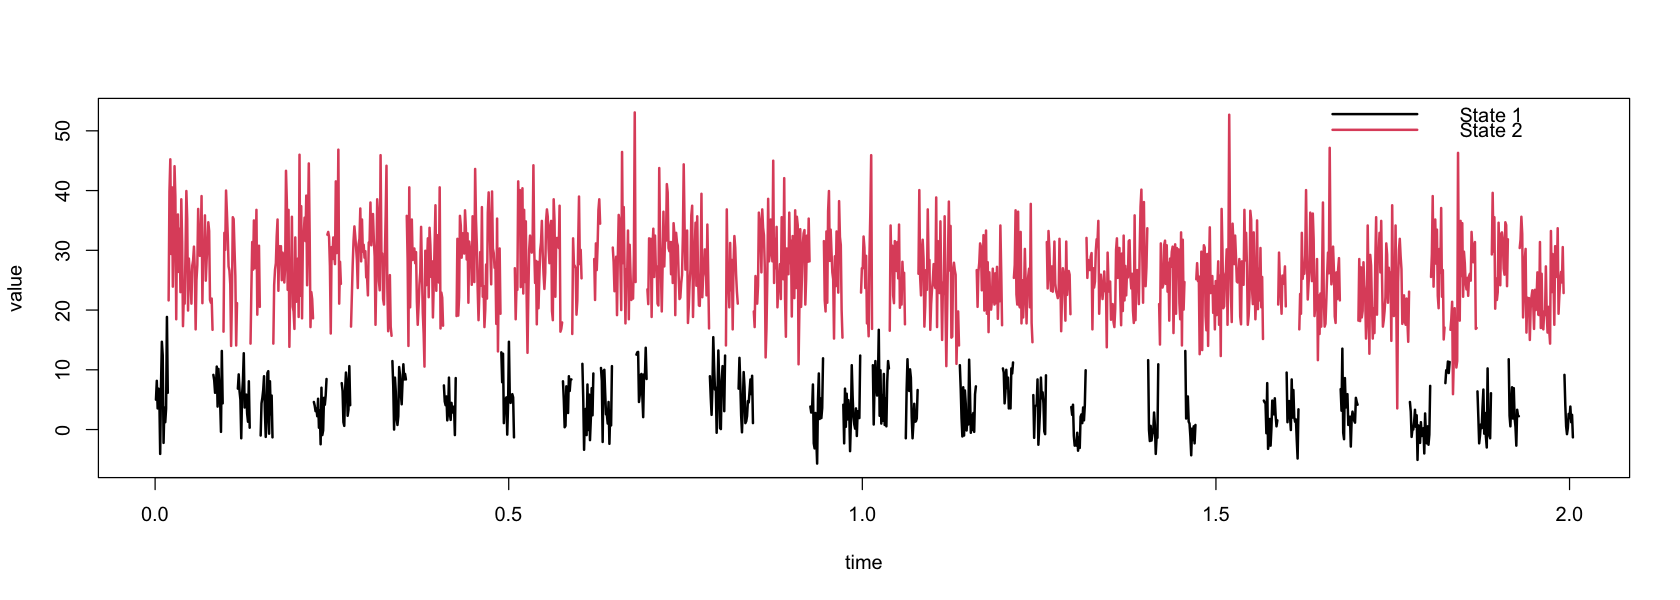

In [8]:
result <- fit_hmm(
  data = dat,
  value = "value",
  time = "time",
  n_states = 2
)

decoded <- decode_hmm(result)

summary_hmm(result)
plot_hmm(decoded, value = "value", time = "time")

## Checking residuals of the model fit

Computing CDFs... done
Computing residuals for value ... done


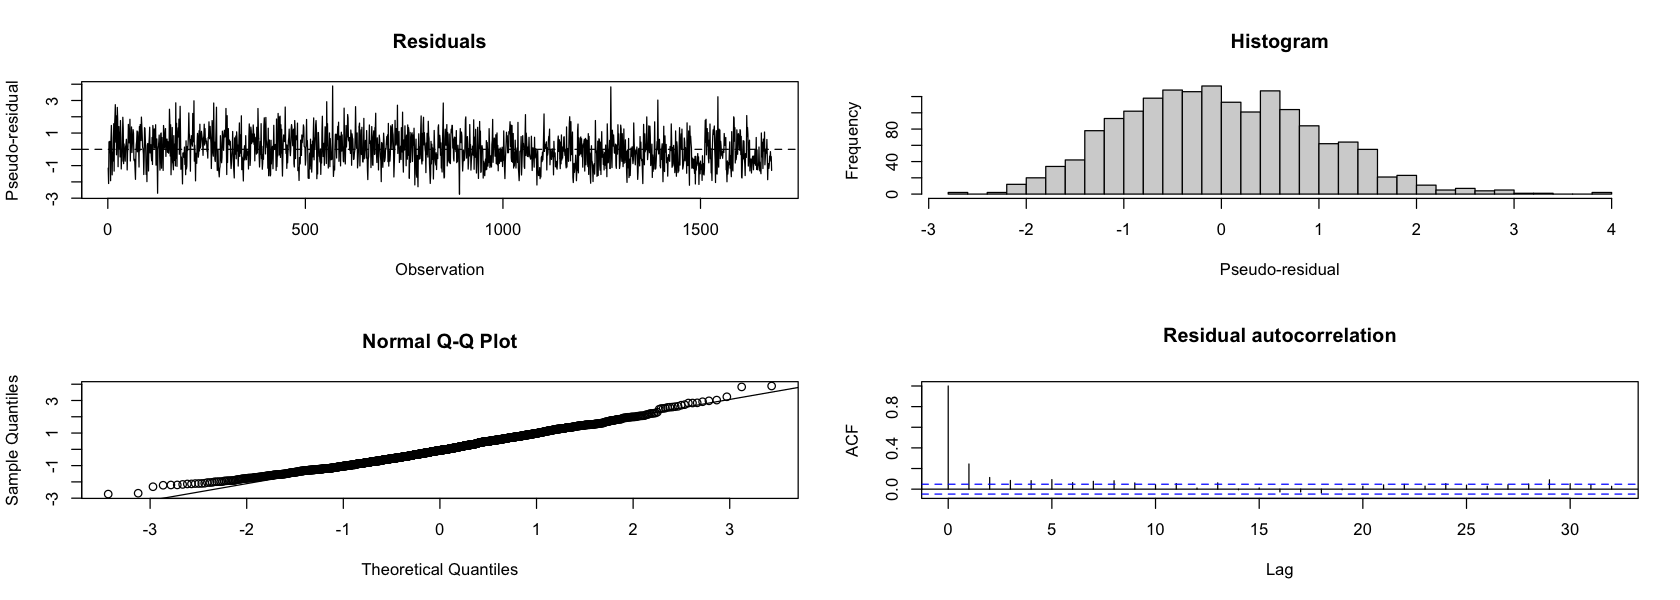

In [9]:
check_residuals(result)

***

## Estimate the blood cell flux [cells/sec] by counting the number of blocks of state=1 and divided by the kymogram recording time

In [15]:
rbc_flux <- count_state_blocks(decoded)/x_t[length(x_t)]
rbc_flux

[1] 16.4611